# 🌍 World Happiness Report Analysis (2015-2025)

## Latar Belakang
World Happiness Report adalah laporan tahunan yang mengukur tingkat kebahagiaan 
warga di berbagai negara berdasarkan beberapa faktor utama seperti GDP, 
dukungan sosial, kebebasan, dan lain-lain.

## Tujuan Analisis
- Negara mana yang paling bahagia dan paling tidak bahagia?
- Bagaimana tren kebahagiaan global dari 2015-2025?
- Faktor apa yang paling mempengaruhi kebahagiaan suatu negara?

## Dataset
- **Sumber:** Kaggle - World Happiness Report 2005-2025
- **Total data:** 1.013 baris setelah cleaning
- **Periode:** 2019-2025

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load data
df = pd.read_csv('world_happiness_report_2005_2025.csv')


In [4]:
# explore data
print(df.shape)
df.head()

(2116, 13)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float

In [12]:
df.describe()

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [13]:
df.isnull().sum()

year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64

In [14]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [37]:
# cleaning
core_cols = ['year', 'country', 'rank_in_year', 'happiness_score']
explained_cols = ['explained_log_gdp_per_capita', 'explained_social_support',
                  'explained_healthy_life_expectancy', 'explained_freedom',
                  'explained_generosity', 'explained_corruption']


df_clean = df.dropna(subset=explained_cols)

print("Data asli   :", df.shape)
print("Data bersih :", df_clean.shape)
df_clean.isnull().sum()

Data asli   : (2116, 13)
Data bersih : (1013, 13)


year                                 0
rank_in_year                         0
country                              0
happiness_score                      0
lower_whisker                        0
upper_whisker                        0
explained_log_gdp_per_capita         0
explained_social_support             0
explained_healthy_life_expectancy    0
explained_freedom                    0
explained_generosity                 0
explained_corruption                 0
dystopia_plus_residual               0
dtype: int64

In [16]:
df_clean = df_clean[df_clean['year'] >= 2015]
print("Setelah filter tahun:", df_clean.shape)

Setelah filter tahun: (1013, 13)


## 🏆 Negara Paling Bahagia di Dunia

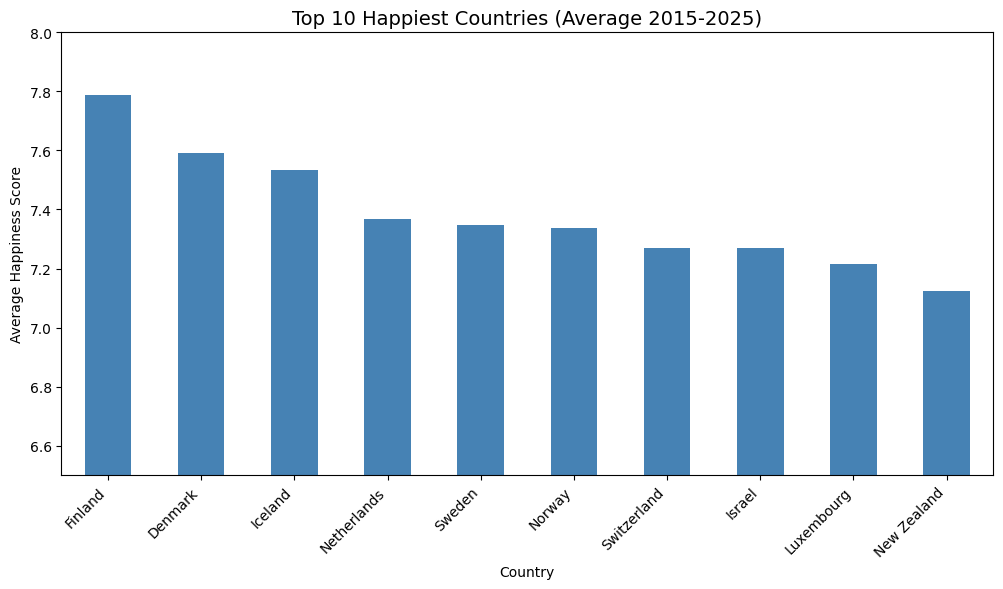

In [28]:
top10 = df_clean.groupby('country')['happiness_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color='steelblue')
plt.title('Top 10 Happiest Countries (Average 2015-2025)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Average Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(6.5, 8.0) 
plt.show()

### Temuan:
- **Finland** konsisten menjadi negara paling bahagia dengan skor rata-rata ~7.8
- **5 dari 10** negara teratas adalah negara Skandinavia (Finland, Denmark, Iceland, Sweden, Norway)
- Negara Skandinavia dikenal dengan sistem kesejahteraan sosial yang kuat — 
  ini konsisten dengan temuan bahwa social support adalah faktor terkuat!

# Tren Kebahagian Global Per Tahun

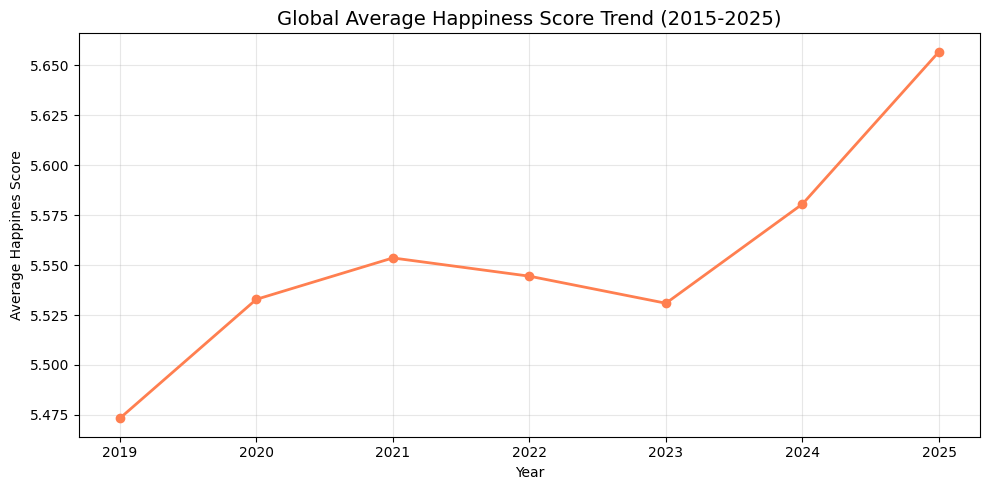

In [29]:
trend = df_clean.groupby('year')['happiness_score'].mean()

plt.figure(figsize=(10, 5))
trend.plot(kind='line', marker='o', color='coral', linewidth=2)
plt.title('Global Average Happiness Score Trend (2015-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Happines Score')
plt.grid(True, alpha= 0.3)
plt.tight_layout()
plt.show()

### Temuan:
- Tren kebahagiaan global **fluktuatif di 2019-2023** — kemungkinan besar 
  dipengaruhi pandemi COVID-19
- Terjadi **lonjakan signifikan di 2023-2025** — menandakan dunia mulai 
  pulih dan lebih bahagia pasca pandemi

## 🔍 Faktor Apa yang Paling Mempengaruhi Kebahagiaan?

Sebelum analisis lebih dalam, saya lihat dulu korelasi antar faktor 
untuk mengetahui mana yang paling berpengaruh terhadap happiness score.

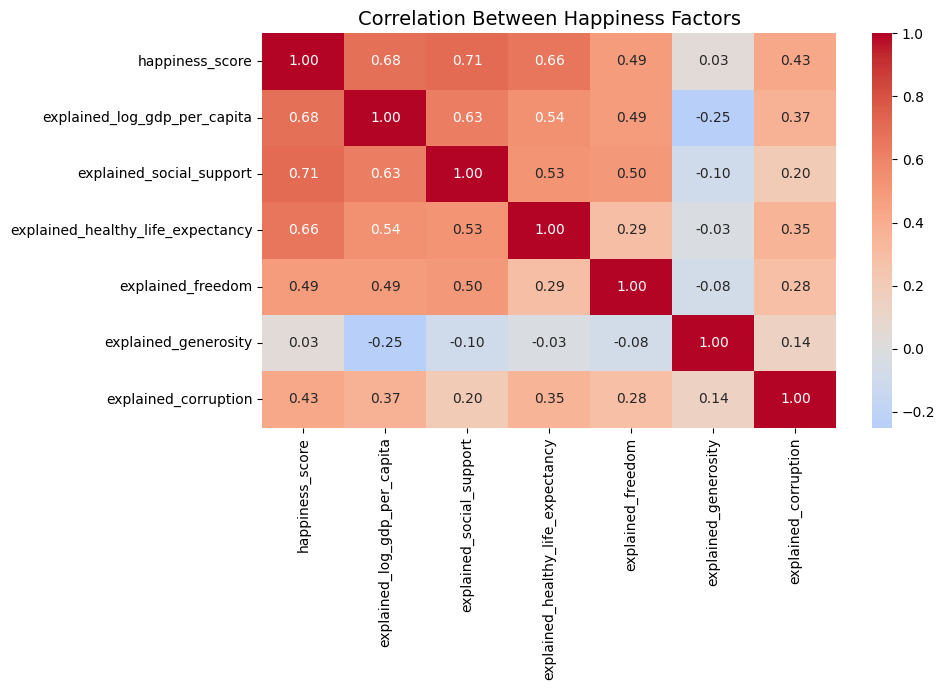

In [20]:
factor_cols = ['happiness_score', 'explained_log_gdp_per_capita', 
               'explained_social_support', 'explained_healthy_life_expectancy',
               'explained_freedom', 'explained_generosity', 'explained_corruption']

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[factor_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Correlation Between Happiness Factors', fontsize=14)
plt.tight_layout()
plt.show()

### Temuan:
- **Social Support (0.71)** adalah faktor terkuat yang mempengaruhi kebahagiaan
- **GDP per Capita (0.68)** berada di posisi kedua
- **Generosity (0.03)** hampir tidak berkorelasi dengan kebahagiaan
- Menariknya, negara dengan GDP tinggi cenderung **kurang dermawan (-0.25)**

# GDP vs Happiness scatter plot:

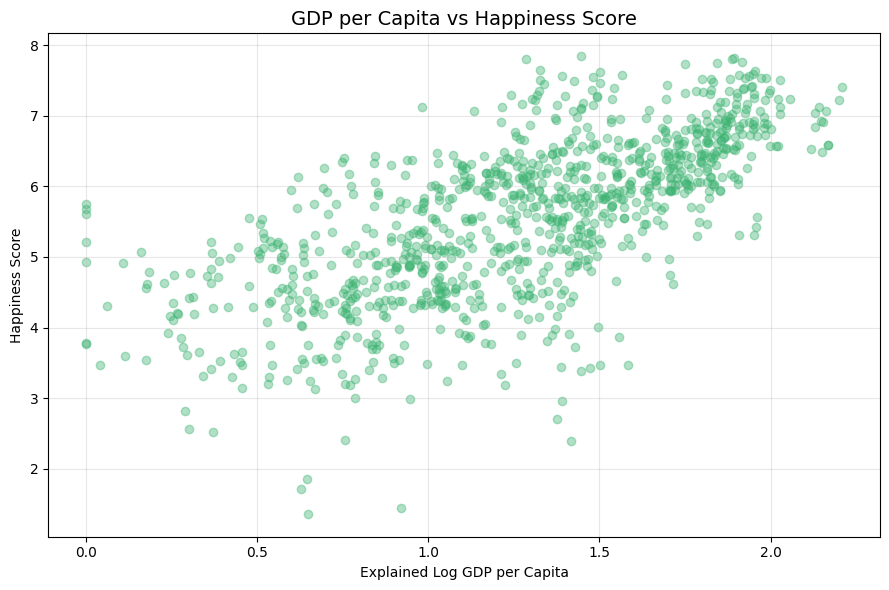

In [36]:
plt.figure(figsize=(9, 6))
plt.scatter(df_clean['explained_log_gdp_per_capita'], 
            df_clean['happiness_score'], alpha=0.4, color='mediumseagreen')
plt.title('GDP per Capita vs Happiness Score', fontsize=14)
plt.xlabel('Explained Log GDP per Capita')
plt.ylabel('Happiness Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

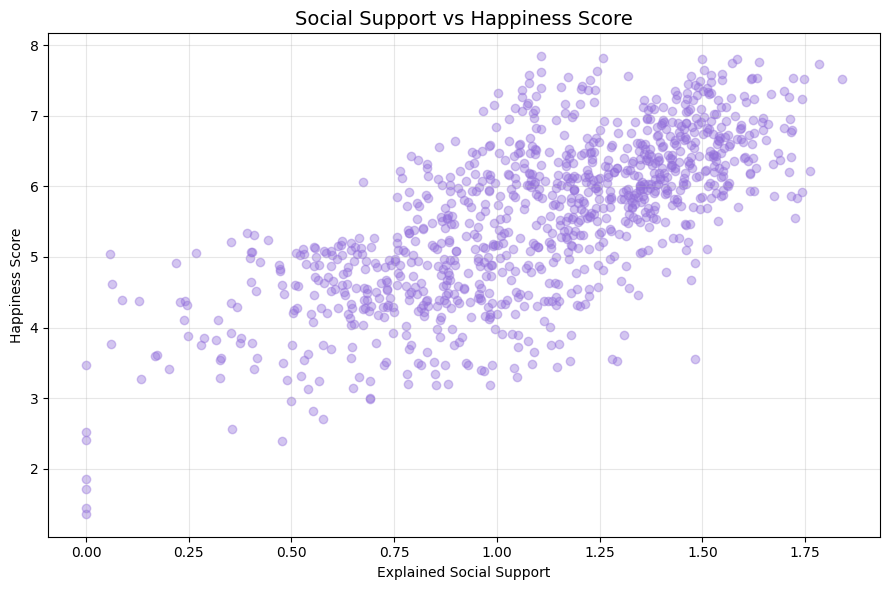

In [33]:
plt.figure(figsize=(9, 6))
plt.scatter(df_clean['explained_social_support'], 
            df_clean['happiness_score'], alpha=0.4, color='mediumpurple')
plt.title('Social Support vs Happiness Score', fontsize=14)
plt.xlabel('Explained Social Support')
plt.ylabel('Happiness Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Negara Paling Tidak Bahagia:

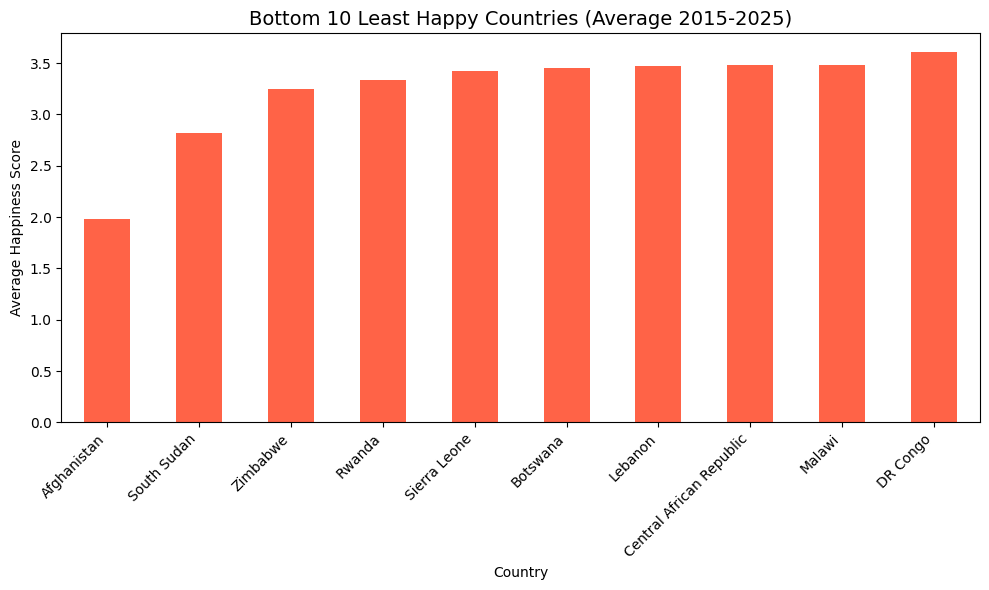

In [22]:
bottom10 = df_clean.groupby('country')['happiness_score'].mean().sort_values().head(10)

plt.figure(figsize=(10, 6))
bottom10.plot(kind='bar', color='tomato')
plt.title('Bottom 10 Least Happy Countries (Average 2015-2025)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Average Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Temuan:
- **Afghanistan** adalah negara paling tidak bahagia dengan skor ~2.0, 
  jauh di bawah posisi kedua South Sudan (~2.8)
- **8 dari 10** negara paling tidak bahagia berada di Afrika
- **Lebanon** masuk bottom 10 kemungkinan karena krisis ekonomi dan 
  politik yang parah sejak 2019

## 📝 Kesimpulan
1. Negara Skandinavia mendominasi top 10 berkat sistem sosial yang kuat
2. Faktor terbesar kebahagiaan bukan hanya uang (GDP), tapi **dukungan sosial**
3. Kesenjangan kebahagiaan global masih sangat besar — gap antara Finland (7.8) 
   dan Afghanistan (2.0) mencapai **5.8 poin!**
4. Kebahagiaan global menunjukkan tren positif di 2025 pasca pandemi

> *"Uang bukan satu-satunya kunci kebahagiaan — negara yang warganya 
> saling mendukung satu sama lain terbukti lebih bahagia."*